In [1]:
import numpy as np
import time
import random
import copy
import matplotlib.pyplot as plt

In [ ]:
class GAPProblem:
    def __init__(self, m, n, profits, resources, capacities):
        self.m = m  
        self.n = n  
        self.profits = np.array(profits)      
        self.resources = np.array(resources)  
        self.capacities = np.array(capacities)
        
        # --- CACHING HASHMAPS ---
        self.repair_cache = {}
        self.eval_cache = {}

    def clear_caches(self):
        self.repair_cache.clear()
        self.eval_cache.clear()

    def repair_assignment(self, assignment):
        key = tuple(assignment)
        if key in self.repair_cache:
            return self.repair_cache[key].copy() # Return copy to prevent accidental overwrites
            
        assignment_copy = np.clip(assignment, 0, self.m - 1).astype(int)
        usage = np.zeros(self.m)
        for j in range(self.n):
            usage[assignment_copy[j]] += self.resources[assignment_copy[j], j]
            
        overloaded = np.where(usage > self.capacities)[0]
        for aOver in overloaded:
            jobsAssigned = np.where(assignment_copy == aOver)[0]
            jobsAssigned = jobsAssigned[np.argsort(-self.resources[aOver, jobsAssigned])]
            
            for j in jobsAssigned:
                if usage[aOver] <= self.capacities[aOver]: break
                
                bestAlt, maxProfitGain = -1, -np.inf
                for aAlt in range(self.m):
                    if aAlt != aOver and (usage[aAlt] + self.resources[aAlt, j] <= self.capacities[aAlt]):
                        gain = self.profits[aAlt, j] - self.profits[aOver, j]
                        if gain > maxProfitGain:
                            maxProfitGain, bestAlt = gain, aAlt
                
                if bestAlt != -1:
                    usage[aOver] -= self.resources[aOver, j]
                    usage[bestAlt] += self.resources[bestAlt, j]
                    assignment_copy[j] = bestAlt
                    
        self.repair_cache[key] = assignment_copy.copy()
        return assignment_copy

    def evaluate(self, assignment):
        key = tuple(assignment)
        if key in self.eval_cache:
            return self.eval_cache[key]
            
        usage = np.zeros(self.m)
        totalProfit = 0
        for j in range(self.n):
            agent = assignment[j]
            totalProfit += self.profits[agent, j]
            usage[agent] += self.resources[agent, j]
            
        violation = sum(max(0, usage[i] - self.capacities[i]) for i in range(self.m))
        penaltyFactor = 10000  
        fitness = totalProfit - (penaltyFactor * violation)
        
        self.eval_cache[key] = fitness
        return fitness

In [ ]:
class BCGA:
    def __init__(self, problem, pop_size=100, gens=500):
        self.p = problem
        self.POP = pop_size
        self.GEN = gens
        self.MUT_MAX = 0.15
        self.MUT_MIN = 0.02
        self.CROSS = 0.8
        self.ELITE_FRAC = 0.1
        # Bits required to represent 'm' agents
        self.bits_per_job = int(np.ceil(np.log2(self.p.m)))
        self.chrom_length = self.p.n * self.bits_per_job

    def decode(self, chrom):
        """Convert binary chromosomes to discrete assignment."""
        assignment = np.zeros(self.p.n, dtype=int)
        for j in range(self.p.n):
            start = j * self.bits_per_job
            bits = chrom[start : start + self.bits_per_job]
            val = int("".join(str(b) for b in bits), 2)
            assignment[j] = val % self.p.m
        return assignment

    def encode(self, assignment):
        """Converts Discrete assignment to binary chromosome."""
        chrom = []
        for val in assignment:
            # Binary string with padding based on bits_per_job
            b_str = format(val, f'0{self.bits_per_job}b')
            chrom.extend([int(b) for b in b_str])
        return np.array(chrom)

    def select(self, pop, fits):
        """Tournament Selection (K=3)."""
        k = 3
        candidates_idx = random.sample(range(len(pop)), k)
        # GAP  is profit maximization hence, max()
        best_idx = max(candidates_idx, key=lambda idx: fits[idx])
        return pop[best_idx]

    def run(self):
        # Initial Population: Random -> Decode -> Repair -> Encode
        pop_list = []
        for _ in range(self.POP):
            chrom = np.random.randint(2, size=self.chrom_length)
            decoded = self.decode(chrom)
            repaired = self.p.repair_assignment(decoded)
            pop_list.append(self.encode(repaired))
        pop = np.array(pop_list)

        best_sol = None
        best_fit = -float('inf')
        history = []
        elite_count = max(1, int(self.ELITE_FRAC * self.POP))

        for t in range(self.GEN):
            # Evaluate current population
            fits = np.array([self.p.evaluate(self.decode(x)) for x in pop])

            # Elitism logic: Descending order for profit
            sort_idx = np.argsort(fits)[::-1]
            elites = pop[sort_idx[:elite_count]].copy()

            if fits[sort_idx[0]] > best_fit:
                best_fit = fits[sort_idx[0]]
                best_sol = self.decode(elites[0]).copy()

            new_pop = list(elites)

            # Adaptive Mutation Rate (Procurement Logic)
            current_mut_rate = self.MUT_MAX - ((self.MUT_MAX - self.MUT_MIN) * (t / self.GEN))

            while len(new_pop) < self.POP:
                p1 = self.select(pop, fits)
                p2 = self.select(pop, fits)

                if random.random() < self.CROSS:
                    # 2-Point Crossover for better structural mixing
                    pt1 = np.random.randint(1, self.chrom_length - 1)
                    pt2 = np.random.randint(pt1 + 1, self.chrom_length)
                    c1 = np.concatenate([p1[:pt1], p2[pt1:pt2], p1[pt2:]])
                    c2 = np.concatenate([p2[:pt1], p1[pt1:pt2], p2[pt2:]])
                else:
                    c1, c2 = p1.copy(), p2.copy()

                for c in [c1, c2]:
                    # Bit-flip Mutation
                    mut_mask = np.random.rand(len(c)) < current_mut_rate
                    c[mut_mask] = 1 - c[mut_mask]

                    # Integrated Repair Step
                    decoded_c = self.decode(c)
                    repaired_c = self.p.repair_assignment(decoded_c)
                    final_chrom = self.encode(repaired_c)
                    
                    new_pop.append(final_chrom)
                    if len(new_pop) >= self.POP: break

            pop = np.array(new_pop[:self.POP])
            history.append(best_fit)

        return best_fit, best_sol, history

In [4]:
# Base Class for Continuous Algorithms
class ContinuousOptimizer:
    def __init__(self, problem, pop_size=100, gens=200):
        self.prob = problem
        self.pop_size = pop_size
        self.gens = gens
        self.dim = problem.n
        self.bounds = (0, problem.m - 1e-5)

    def decode(self, continuous_vector):
        return np.floor(np.clip(continuous_vector, self.bounds[0], self.bounds[1])).astype(int)

In [ ]:
class RCGA:
    def __init__(self, problem, pop_size=100, gens=500):
        self.p = problem
        self.POP = pop_size
        self.GEN = gens
        self.MUT_MAX = 0.20 # In Real coding we use higher mutation
        self.MUT_MIN = 0.05
        self.CROSS = 0.8
        self.ELITE_FRAC = 0.1
        # Range: 0 to m-1 Agents
        self.bounds = (0, self.p.m - 1e-5)

    def decode(self, chrom):
        """Converts continuous values to discrete agent IDs."""
        return np.floor(np.clip(chrom, self.bounds[0], self.bounds[1])).astype(int)

    def select(self, pop, fits):
        """Tournament Selection (K=3)."""
        k = 3
        candidates_idx = random.sample(range(len(pop)), k)
        best_idx = max(candidates_idx, key=lambda idx: fits[idx])
        return pop[best_idx]

    def run(self):
        self.p.clear_caches()
        # 1. Initial Population: Random -> Decode -> Repair -> Repopulate (Continuous)
        # Note: We bring back repaired discrete solutions in continuous space
        pop = []
        for _ in range(self.POP):
            chrom = np.random.uniform(self.bounds[0], self.bounds[1], self.p.n)
            repaired_discrete = self.p.repair_assignment(self.decode(chrom))
            pop.append(repaired_discrete.astype(float)) # Store as float for RCGA
        pop = np.array(pop)

        best_sol = None
        best_fit = -float('inf')
        history = []
        elite_count = max(1, int(self.ELITE_FRAC * self.POP))

        for t in range(self.GEN):
            # Evaluate
            fits = np.array([self.p.evaluate(self.decode(x)) for x in pop])

            # Elitism
            sort_idx = np.argsort(fits)[::-1]
            elites = pop[sort_idx[:elite_count]].copy()

            if fits[sort_idx[0]] > best_fit:
                best_fit = fits[sort_idx[0]]
                best_sol = self.decode(elites[0]).copy()

            new_pop = list(elites)

            # Adaptive Mutation Rate (Decreases over time)
            current_mut_rate = self.MUT_MAX - ((self.MUT_MAX - self.MUT_MIN) * (t / self.GEN))

            while len(new_pop) < self.POP:
                p1 = self.select(pop, fits)
                p2 = self.select(pop, fits)

                if random.random() < self.CROSS:
                    # Arithmetic Crossover
                    alpha = np.random.rand(self.p.n)
                    c1 = alpha * p1 + (1 - alpha) * p2
                    c2 = (1 - alpha) * p1 + alpha * p2
                else:
                    c1, c2 = p1.copy(), p2.copy()

                for c in [c1, c2]:
                    # Gaussian Mutation
                    if random.random() < current_mut_rate:
                        # Every job can get any agent among 0 se m-1
                        mutation_mask = np.random.rand(self.p.n) < 0.1 # 10% genes mutate
                        c[mutation_mask] = np.random.uniform(self.bounds[0], self.bounds[1], np.sum(mutation_mask))

                    # Integrated Repair Step
                    decoded_c = self.decode(c)
                    repaired_discrete = self.p.repair_assignment(decoded_c)
                    new_pop.append(repaired_discrete.astype(float))

                    if len(new_pop) >= self.POP: break

            pop = np.array(new_pop[:self.POP])
            history.append(best_fit)

        return best_fit, best_sol, history

In [6]:
class PSO(ContinuousOptimizer):
    def run(self):
        self.prob.clear_caches()
        # Inertia weight decay
        w_max, w_min = 0.9, 0.4
        c1, c2 = 2.0, 2.0 # Standard coefficients
        pos = np.random.uniform(self.bounds[0], self.bounds[1], (self.pop_size, self.dim))
        vel = np.random.uniform(-1, 1, (self.pop_size, self.dim))
        pbest_pos = pos.copy()
        pbest_fit = np.array([self.prob.evaluate(self.prob.repair_assignment(self.decode(p))) for p in pos])
        gbest_idx = np.argmax(pbest_fit)
        gbest_fit = pbest_fit[gbest_idx]
        gbest_pos = pbest_pos[gbest_idx].copy()
        history = []

        for gen in range(self.gens):
            w = w_max - (gen/self.gens)*(w_max - w_min) # Adaptive Weight
            for i in range(self.pop_size):
                r1, r2 = np.random.rand(self.dim), np.random.rand(self.dim)
                vel[i] = w*vel[i] + c1*r1*(pbest_pos[i]-pos[i]) + c2*r2*(gbest_pos-pos[i])
                pos[i] = np.clip(pos[i] + vel[i], self.bounds[0], self.bounds[1])
                
                curr_fit = self.prob.evaluate(self.prob.repair_assignment(self.decode(pos[i])))
                if curr_fit > pbest_fit[i]:
                    pbest_fit[i], pbest_pos[i] = curr_fit, pos[i].copy()
                    if curr_fit > gbest_fit:
                        gbest_fit, gbest_pos = curr_fit, pos[i].copy()
            history.append(gbest_fit)
        return gbest_fit, self.prob.repair_assignment(self.decode(gbest_pos)), history

In [7]:
class TLBO(ContinuousOptimizer):
    def run(self):
        self.prob.clear_caches()
        pop = np.random.uniform(self.bounds[0], self.bounds[1], (self.pop_size, self.dim))
        fits = np.array([self.prob.evaluate(self.prob.repair_assignment(self.decode(p))) for p in pop])
        history = []
        for gen in range(self.gens):
            # Teacher Phase
            best_idx = np.argmax(fits)
            teacher = pop[best_idx]
            mean_v = np.mean(pop, axis=0)
            for i in range(self.pop_size):
                tf = np.random.randint(1, 3) # Randomly 1 or 2
                new_sol = np.clip(pop[i] + np.random.rand() * (teacher - tf * mean_v), self.bounds[0], self.bounds[1])
                new_fit = self.prob.evaluate(self.prob.repair_assignment(self.decode(new_sol)))
                if new_fit > fits[i]:
                    pop[i], fits[i] = new_sol, new_fit
            
            # Learner Phase
            for i in range(self.pop_size):
                partner = np.random.choice([idx for idx in range(self.pop_size) if idx != i])
                if fits[i] > fits[partner]:
                    diff = pop[i] - pop[partner]
                else:
                    diff = pop[partner] - pop[i]
                new_sol = np.clip(pop[i] + np.random.rand() * diff, self.bounds[0], self.bounds[1])
                new_fit = self.prob.evaluate(self.prob.repair_assignment(self.decode(new_sol)))
                if new_fit > fits[i]:
                    pop[i], fits[i] = new_sol, new_fit
            history.append(np.max(fits))
        return np.max(fits), self.prob.repair_assignment(self.decode(pop[np.argmax(fits)])), history

In [ ]:
class ACO:
    def __init__(self, problem, pop_size=50, gens=200, alpha=1.0, beta=2.5, rho=0.15):
        self.prob = problem
        self.pop_size = pop_size
        self.gens = gens
        self.alpha, self.beta, self.rho = alpha, beta, rho

    def run(self):
        self.prob.clear_caches() # Keeps execution time fair
        eta = self.prob.profits / (self.prob.resources + 1e-6)
        tau = np.ones((self.prob.m, self.prob.n))
        best_fit, best_sol, history = -np.inf, None, []

        for gen in range(self.gens):
            pop_sols, pop_fits = [], []
            for _ in range(self.pop_size):
                sol = np.zeros(self.prob.n, dtype=int)
                for j in range(self.prob.n):
                    attraction = (tau[:, j]**self.alpha) * (eta[:, j]**self.beta)
                    
                    # FAST ROULETTE WHEEL
                    cumsum_probs = np.cumsum(attraction)
                    cumsum_probs /= cumsum_probs[-1] # Normalize
                    sol[j] = np.searchsorted(cumsum_probs, np.random.rand())
                
                repaired = self.prob.repair_assignment(sol)
                fit = self.prob.evaluate(repaired)
                pop_sols.append(repaired)
                pop_fits.append(fit)
                
                if fit > best_fit:
                    best_fit, best_sol = fit, repaired.copy()
            
            tau *= (1 - self.rho)
            sorted_indices = np.argsort(pop_fits)[::-1]
            top_n = max(1, self.pop_size // 5) 
            for idx in sorted_indices[:top_n]:
                reward = 1.0 / (1 + (best_fit - pop_fits[idx])/best_fit)
                for j in range(self.prob.n):
                    tau[pop_sols[idx][j], j] += reward
                    
            history.append(best_fit)
        return best_fit, best_sol, history

In [9]:
class DE(ContinuousOptimizer):
    def run(self, F=0.8, CR=0.9):
        self.prob.clear_caches()
        pop = np.random.uniform(self.bounds[0], self.bounds[1], (self.pop_size, self.dim))
        fits = np.array([self.prob.evaluate(self.prob.repair_assignment(self.decode(p))) for p in pop])
        history = []
        for gen in range(self.gens):
            for i in range(self.pop_size):
                # Strategy: DE/best/1/bin
                best_vec = pop[np.argmax(fits)]
                r1, r2 = pop[np.random.choice(self.pop_size, 2, replace=False)]
                mutant = np.clip(best_vec + F * (r1 - r2), self.bounds[0], self.bounds[1])
                
                cross_mask = np.random.rand(self.dim) < CR
                trial = np.where(cross_mask, mutant, pop[i])
                
                trial_fit = self.prob.evaluate(self.prob.repair_assignment(self.decode(trial)))
                if trial_fit > fits[i]:
                    pop[i], fits[i] = trial, trial_fit
            history.append(np.max(fits))
        return np.max(fits), self.prob.repair_assignment(self.decode(pop[np.argmax(fits)])), history

In [10]:
class ABC(ContinuousOptimizer):
    def run(self, limit=30):
        self.prob.clear_caches()
        pop = np.random.uniform(self.bounds[0], self.bounds[1], (self.pop_size, self.dim))
        fits = np.array([self.prob.evaluate(self.prob.repair_assignment(self.decode(p))) for p in pop])
        trials = np.zeros(self.pop_size)
        history = []
        
        best_idx = np.argmax(fits)
        best_fit = fits[best_idx]
        best_pos = pop[best_idx].copy()

        for gen in range(self.gens):
            # Employed Bees Phase
            for i in range(self.pop_size):
                k = np.random.choice([idx for idx in range(self.pop_size) if idx != i])
                phi = np.random.uniform(-1, 1, self.dim)
                # Global best guided search
                new_sol = pop[i] + phi * (pop[i] - pop[k]) + np.random.rand()*(best_pos - pop[i])
                new_sol = np.clip(new_sol, self.bounds[0], self.bounds[1])
                
                new_fit = self.prob.evaluate(self.prob.repair_assignment(self.decode(new_sol)))
                if new_fit > fits[i]:
                    pop[i], fits[i], trials[i] = new_sol, new_fit, 0
                else:
                    trials[i] += 1

            # Onlooker Bees Phase
            # Probability proportional to fitness
            prob_dist = (fits - np.min(fits)) / (np.sum(fits - np.min(fits)) + 1e-9)
            for _ in range(self.pop_size):
                i = np.random.choice(self.pop_size, p=prob_dist)
                k = np.random.choice([idx for idx in range(self.pop_size) if idx != i])
                new_sol = np.clip(pop[i] + np.random.uniform(-1,1)*(pop[i]-pop[k]), self.bounds[0], self.bounds[1])
                new_fit = self.prob.evaluate(self.prob.repair_assignment(self.decode(new_sol)))
                if new_fit > fits[i]:
                    pop[i], fits[i], trials[i] = new_sol, new_fit, 0
                else:
                    trials[i] += 1

            # Scout Bees Phase
            for i in range(self.pop_size):
                if trials[i] > limit:
                    pop[i] = np.random.uniform(self.bounds[0], self.bounds[1], self.dim)
                    fits[i] = self.prob.evaluate(self.prob.repair_assignment(self.decode(pop[i])))
                    trials[i] = 0

            if np.max(fits) > best_fit:
                best_fit = np.max(fits)
                best_pos = pop[np.argmax(fits)].copy()
            
            history.append(best_fit)
            
        return best_fit, self.prob.repair_assignment(self.decode(best_pos)), history

In [ ]:
# Data Parser and Execution Engine

def parse_gap_data(raw_data):
    """Parses standard OR-library GAP file formats."""
    lines = raw_data.replace('\n', ' ').split()
    tokens = [int(x) for x in lines if x.strip()]
    
    num_instances = tokens[0] # first token is number of instances
    ptr = 1
    
    m = tokens[ptr]
    n = tokens[ptr+1]
    ptr += 2
    
    profits = np.array(tokens[ptr:ptr+(m*n)]).reshape((m, n))
    ptr += (m*n)
    
    resources = np.array(tokens[ptr:ptr+(m*n)]).reshape((m, n))
    ptr += (m*n)
    
    capacities = np.array(tokens[ptr:ptr+m])
    
    return GAPProblem(m, n, profits, resources, capacities)

In [ ]:
def run_experiment(num_runs=20):
    # 1. Instances Data
    instances_raw = {
        30: """ 5 10 30
              25 16 17 24 15 24 24 17 23 16 21 18 18 18 18 20 16 15 25 15 16 23 22 18 23 18 19 20 21 19
              16 17 19 18 17 23 15 25 25 16 16 23 21 23 25 19 16 18 16 21 24 15 21 19 20 16 18 25 20 22
              19 19 15 25 24 25 16 23 15 20 16 19 18 20 15 17 16 17 21 20 18 19 22 20 19 21 18 20 25 17
              17 21 21 21 19 20 24 15 21 15 18 23 18 16 16 18 24 16 22 16 22 19 17 17 22 19 21 16 24 17
              18 23 23 17 25 21 22 17 20 24 18 25 16 15 16 18 23 17 25 17 17 23 24 23 19 16 16 22 22 19
              24 18 20 18 19 16 22 18 19 23 18 23 21 24 22 25 21 18 21 16 21 22 18 22 15 19 16 22 16 17
              20 21 15 24 20 19 16 24 23 24 22 20 24 18 24 20 17 23 17 22 18 21 25 17 21 18 24 21 15 25
              15 23 19 21 17 16 22 23 16 15 19 21 15 18 18 21 25 15 15 15 20 21 18 19 18 21 25 23 25 21
              17 25 16 24 16 22 16 15 15 17 25 17 20 21 16 16 17 17 25 21 18 17 20 19 23 18 17 20 17 17
              17 21 23 22 23 25 25 22 24 18 24 22 15 24 15 16 19 22 25 19 24 17 16 17 17 25 19 16 23 22
              5 25 21 11 25 10 15 17 10 9 10 23 13 13 23 14 24 17 16 21 22 23 7 25 17 17 24 24 7 8
              25 14 19 21 22 11 19 14 12 22 9 10 7 12 6 9 5 23 24 16 8 15 17 22 20 6 18 15 7 7
              12 14 15 25 18 25 6 7 10 17 12 10 12 19 10 12 12 10 7 21 5 5 19 21 12 6 14 6 19 24
              24 11 18 14 9 13 18 14 11 12 9 14 12 18 8 19 24 13 7 17 22 20 24 15 12 12 20 21 6 22
              15 9 19 9 13 19 25 16 14 17 6 9 15 12 20 21 9 17 19 14 23 19 25 22 13 14 14 23 15 23
              25 22 12 6 11 25 15 13 13 9 9 13 19 10 18 23 14 8 9 19 15 21 10 5 23 17 22 11 17 5
              20 10 18 7 12 14 12 18 8 25 25 14 16 25 23 5 22 22 7 24 12 13 5 8 12 25 24 19 15 14
              15 18 21 17 7 5 10 10 25 13 23 10 7 7 20 18 21 12 24 10 7 25 20 13 19 18 16 7 9 6
              20 21 9 22 18 7 5 21 15 13 8 23 21 21 17 11 24 11 12 15 19 8 7 8 18 22 18 12 18 17
              14 6 10 23 12 23 12 9 20 25 24 23 20 12 25 17 18 20 18 25 17 20 19 12 5 6 10 5 7 15
              40 30 32 37 39 35 38 34 36 37""",
        
        40: """ 5 10 40
              17 21 25 19 24 22 24 20 23 15 16 17 23 21 20 21 22 19 24 22 16 23 24 16 24 15 17 17 19 19 25 18 21 15 21 23 18 21 19 16
              16 16 18 15 16 22 20 24 25 23 20 25 15 16 22 19 22 16 23 18 21 24 22 22 17 25 15 24 16 16 18 20 15 15 16 24 16 20 17 21
              25 24 24 18 20 19 25 17 19 19 22 18 19 19 24 22 22 20 16 25 19 25 19 21 20 24 20 20 15 24 23 23 17 15 24 20 23 19 19 22
              21 18 19 21 23 15 17 19 25 25 15 20 18 18 15 21 22 16 25 17 17 16 15 17 24 25 24 22 23 24 20 17 20 16 24 18 21 22 20 16
              23 22 15 17 25 25 24 20 21 23 17 23 21 18 18 22 18 15 15 21 19 24 16 19 20 16 23 17 15 24 15 24 19 21 17 16 16 22 16 24
              19 17 19 24 25 23 19 15 22 23 15 22 19 19 17 16 22 19 20 22 25 15 24 24 24 22 22 19 21 23 24 17 23 17 20 22 20 25 19 20
              17 25 23 21 21 16 18 19 20 19 17 21 23 16 19 23 23 18 24 15 19 22 25 21 19 17 25 18 22 21 16 15 20 15 19 24 25 18 15 21
              15 23 18 15 24 18 16 24 25 24 17 25 21 22 22 18 20 16 16 23 23 23 15 24 20 20 18 25 16 22 20 23 15 17 19 16 18 16 16 23
              18 23 24 21 18 16 18 24 16 21 21 23 25 17 19 20 17 15 23 16 24 21 22 15 19 22 22 17 25 21 16 15 21 20 25 21 16 17 15 21
              21 16 17 18 18 23 18 22 24 22 21 17 24 25 24 15 25 17 15 19 20 20 25 25 18 25 17 21 21 15 24 16 24 17 22 15 22 19 24 17
              9 14 23 14 12 6 15 16 15 12 14 18 9 22 8 23 6 19 6 8 8 15 7 16 24 5 18 16 13 13 11 7 19 19 15 21 20 18 11 8
              21 24 24 19 14 22 9 24 19 24 11 23 18 22 9 9 14 15 21 5 25 5 20 13 7 6 8 16 21 22 5 18 10 20 8 9 14 9 5 22
              18 12 6 14 17 7 24 20 19 10 13 25 23 7 6 9 17 9 6 21 24 13 18 5 21 21 15 11 15 15 15 18 21 9 22 8 8 18 13 12
              23 7 9 13 7 17 14 10 17 9 11 22 25 19 12 5 20 5 24 22 7 11 24 19 8 15 9 21 11 9 15 12 18 25 8 14 20 21 22 8
              7 8 13 10 12 25 7 5 14 17 16 15 10 9 6 16 6 23 23 10 16 5 16 11 23 15 6 13 12 21 10 15 21 12 14 14 24 22 13 5
              17 9 22 8 19 8 7 11 14 14 17 23 25 21 12 20 8 20 9 5 8 16 16 23 22 20 17 21 11 12 9 15 21 17 13 18 23 6 8 20
              14 12 24 12 14 5 24 11 13 21 15 18 14 18 5 11 21 16 5 17 6 10 21 11 13 24 13 25 10 21 11 22 11 16 15 17 21 11 21 24
              22 20 21 12 17 24 21 7 9 23 13 11 19 17 17 20 14 10 11 16 8 7 21 16 24 9 16 15 10 23 10 13 9 6 18 23 19 22 13 18
              6 11 16 17 6 8 18 24 19 9 18 18 7 13 11 20 19 22 19 20 14 10 6 6 25 7 8 18 19 17 6 25 13 12 22 23 8 12 5 19
              7 14 11 6 11 25 18 10 9 10 13 23 12 17 11 14 12 19 20 8 8 8 20 25 19 21 25 23 23 11 19 13 21 25 20 22 16 8 24 20
              44 48 46 47 43 48 49 49 46 51""",

        50: """ 5 10 50
              10 25 22 21 24 20 17 21 13 23 16 20 16 16 17 20 19 24 21 16 13 20 15 10 11 17 18 24 11 20 17 22 11 15 22 22 19 15 15 24 11 20 16 17 20 13 24 19 20 24
              10 17 16 21 16 24 13 18 14 12 18 18 15 24 24 15 12 12 11 11 13 14 14 15 12 13 10 11 19 22 13 21 24 21 15 24 16 25 23 13 21 12 13 16 18 20 23 18 19 18
              23 25 12 24 16 24 16 14 11 23 14 15 13 23 17 12 13 18 16 16 10 15 11 21 13 14 12 18 24 25 21 22 18 12 15 14 13 15 21 15 12 10 13 24 25 19 17 11 21 10
              23 10 10 14 25 13 13 11 19 13 24 13 19 19 20 18 15 11 10 13 25 12 18 24 11 17 18 22 19 11 21 23 25 22 15 22 21 11 17 16 21 24 11 15 14 11 14 11 23 17
              11 18 14 13 20 17 14 21 18 15 12 11 13 15 11 23 15 17 24 17 20 15 19 14 16 13 15 19 16 21 11 13 14 11 19 17 21 11 18 15 11 20 14 17 14 20 16 18 11 21
              17 10 22 24 12 14 10 21 15 25 17 15 15 14 13 16 13 19 12 21 20 15 12 22 20 22 10 16 24 24 15 12 24 14 18 23 19 23 20 13 13 22 11 18 25 15 24 18 10 19
              12 25 20 21 22 24 12 22 14 15 15 12 17 17 11 23 14 23 14 13 20 22 11 21 19 12 18 24 16 11 22 15 11 14 16 18 17 22 16 22 19 17 10 19 12 21 13 18 22 23
              11 18 14 23 18 11 15 19 17 12 18 19 25 24 14 17 21 20 21 13 20 11 21 17 18 12 15 17 15 11 18 18 16 14 18 24 15 19 16 24 13 23 17 13 12 15 18 21 13 18
              16 24 19 17 25 22 24 15 21 12 15 13 14 22 11 24 17 20 13 13 13 17 18 17 14 24 23 22 16 14 18 14 17 20 11 21 18 17 24 12 10 19 16 17 11 19 24 17 20 23
              13 23 21 23 24 16 15 15 17 19 22 21 21 24 14 10 18 11 24 16 15 19 18 15 15 20 11 24 20 23 17 10 10 12 18 22 25 19 22 16 12 11 17 12 19 24 20 17 22 23
              20 16 7 12 15 19 9 23 10 15 20 23 20 20 9 16 5 16 14 8 19 18 23 13 12 17 6 14 14 19 21 20 11 12 20 24 7 18 11 15 22 6 7 6 8 9 17 16 24 18
              8 11 17 22 7 11 20 9 17 13 12 7 7 13 11 21 18 16 17 8 18 10 11 18 13 9 6 11 20 9 14 22 8 11 15 23 23 21 15 21 10 10 15 9 21 9 15 15 10 16
              17 22 5 6 7 17 13 16 9 13 19 20 6 10 24 24 6 8 7 14 9 11 11 20 20 22 13 6 9 20 9 9 16 18 17 8 12 14 18 23 11 14 19 17 21 23 20 22 12 19
              25 13 9 21 10 15 15 20 6 21 17 11 6 8 14 23 11 22 14 18 20 17 16 23 16 11 7 23 8 21 6 6 5 22 12 21 18 18 10 21 8 23 23 15 20 8 24 20 7 12
              24 11 12 12 7 22 18 14 17 16 10 13 13 12 5 15 15 25 6 13 24 6 19 22 18 6 8 22 20 15 11 10 10 22 14 18 24 16 14 8 15 16 15 9 7 6 5 12 17 18
              18 21 24 15 15 16 6 6 8 16 10 16 19 23 24 24 11 7 12 6 8 15 16 12 25 16 18 12 10 9 23 6 19 16 24 17 12 15 12 10 16 11 11 7 17 24 21 20 22 18
              8 20 16 19 16 18 24 10 20 19 17 19 13 18 8 21 8 15 12 14 6 20 15 13 22 12 17 15 21 23 8 22 17 7 14 24 22 22 19 7 19 17 17 14 8 17 15 21 14 8
              12 18 16 18 7 18 8 16 18 11 15 16 18 9 20 22 12 23 16 9 22 16 24 19 6 23 17 15 21 23 15 24 7 15 11 23 19 14 13 8 23 23 22 8 15 11 11 18 18 11
              21 21 23 13 11 20 7 10 20 10 18 12 17 25 7 20 19 12 18 18 11 22 24 19 10 17 11 19 20 18 15 11 19 20 14 5 16 18 9 14 24 8 12 15 19 7 19 10 25 20
              12 18 16 10 19 19 16 8 13 24 8 19 6 8 11 23 10 11 22 16 14 17 9 17 22 9 12 7 23 10 5 24 6 18 17 18 20 6 16 6 10 5 23 10 19 8 7 13 22 6
              69 69 68 70 72 60 55 58 61 57""",

        60: """5 10 60
              25 18 15 16 18 25 19 18 25 23 19 25 19 21 24 16 18 23 18 17 25 20 24 21 17 19 24 25 17 19 19 25 20 17 21 20 20 17 19 25 25 19 23 24 20 16 21 24 17 15 17 19 15 21 25 16 21 20 24 22
              21 21 15 23 23 22 20 22 21 24 20 19 23 24 23 23 22 22 15 18 20 19 20 24 22 20 20 20 20 17 20 24 18 19 22 17 21 17 19 17 22 22 18 22 20 17 19 15 15 19 23 22 24 23 17 21 25 23 20 19
              21 17 24 17 24 15 22 24 20 18 21 23 19 24 23 22 22 21 16 18 21 22 25 22 17 25 22 22 24 22 25 20 16 19 23 20 18 23 23 19 19 21 17 22 15 16 23 24 17 22 23 18 24 16 20 25 19 17 22 21
              21 20 22 15 23 24 25 22 18 16 23 24 20 21 15 21 17 20 24 22 24 25 16 17 18 20 25 18 24 24 24 22 19 20 15 20 17 19 16 23 15 22 22 24 15 16 20 17 21 24 24 24 24 25 19 24 25 16 22 19
              24 23 22 19 18 16 23 18 22 24 25 16 23 21 17 18 19 17 25 17 18 23 24 18 24 23 23 15 19 18 24 19 19 24 24 24 15 21 21 24 24 19 23 24 21 23 24 22 18 19 24 15 17 17 25 17 24 16 19 21
              16 21 19 22 16 16 17 23 25 16 18 22 15 25 20 15 18 23 22 16 17 17 16 24 24 16 17 23 19 23 15 17 24 19 24 24 24 16 22 16 18 23 23 20 16 25 23 17 18 23 24 19 22 19 19 18 21 21 22 17
              23 23 19 18 19 19 21 24 22 16 17 25 24 17 23 17 20 25 25 22 17 24 17 17 23 23 16 17 19 19 23 24 17 25 18 19 18 16 17 17 24 23 17 19 15 23 22 17 23 21 15 19 18 22 23 16 16 22 16 21
              24 16 15 25 16 15 20 20 22 18 21 19 21 19 17 17 17 22 25 17 20 25 15 17 20 16 23 20 23 22 23 15 21 24 21 23 19 24 17 24 25 18 24 21 20 18 22 15 16 18 23 24 25 20 20 21 17 15 24 21
              18 18 18 19 18 24 22 19 25 15 16 23 17 16 18 22 21 18 21 18 20 18 16 24 17 22 24 18 22 18 24 23 23 25 20 23 18 22 21 18 24 17 15 25 23 16 22 24 18 21 16 24 22 18 25 23 23 18 16 22
              16 18 19 18 18 24 24 23 25 16 20 22 25 16 20 18 19 24 24 25 22 23 23 24 18 24 16 21 17 22 22 16 15 17 19 23 15 19 22 22 23 23 16 20 22 24 20 20 23 16 24 17 22 17 19 25 16 16 19 16
              17 25 6 14 16 12 19 19 5 16 23 16 15 22 19 10 25 7 24 9 7 24 22 23 10 25 21 16 13 17 9 6 16 23 11 22 14 22 5 14 9 19 24 16 6 21 19 11 22 22 19 24 12 20 15 17 21 17 25 19
              6 24 12 24 14 22 11 10 25 12 20 17 18 22 11 15 20 20 21 12 5 5 25 15 24 17 7 21 11 12 24 16 12 5 9 11 14 7 14 9 13 7 25 12 6 10 7 15 13 22 6 10 5 21 5 16 16 13 5 23
              21 21 7 5 20 16 9 14 22 12 9 8 14 17 22 9 17 8 12 15 24 19 6 8 16 14 14 23 14 23 5 21 17 25 13 23 23 12 20 19 16 15 22 19 18 7 5 20 19 9 23 14 14 11 20 15 25 17 12 13
              22 14 19 7 5 20 19 5 20 7 12 8 13 18 16 9 23 16 16 9 25 8 13 16 6 8 5 18 12 5 12 16 12 25 5 24 23 23 25 22 17 17 21 24 16 7 17 9 13 24 22 25 25 23 12 12 8 24 14 8
              17 10 18 13 14 18 6 6 11 9 12 20 15 12 18 18 11 7 9 25 13 9 10 9 15 10 19 15 15 14 25 6 12 21 9 10 18 20 13 17 17 21 15 9 22 11 14 14 13 16 12 5 14 18 24 9 19 14 9 24
              24 23 6 13 9 17 18 21 10 15 15 18 14 15 11 24 20 24 16 20 23 25 9 21 21 13 9 24 12 8 14 21 16 25 20 23 8 16 20 10 5 16 11 20 10 11 21 15 12 12 21 10 19 18 10 25 23 16 8 25
              5 21 24 13 21 11 18 12 24 22 20 21 16 18 8 25 7 19 11 12 18 5 15 7 12 5 23 16 12 5 8 24 25 10 13 24 22 20 12 16 18 9 21 17 19 6 21 12 6 9 24 10 8 13 13 13 23 25 8 22
              9 19 23 7 5 8 16 17 21 15 15 12 21 24 15 6 7 11 5 13 10 16 19 9 22 8 21 17 7 8 25 23 20 8 14 16 5 16 5 10 17 6 18 9 19 9 11 18 23 14 24 13 20 10 22 19 6 15 18 15
              23 15 16 20 19 23 8 15 24 25 25 5 13 14 12 25 5 11 23 24 18 7 17 10 25 21 13 19 18 6 8 9 21 18 5 12 8 7 19 24 7 9 22 7 9 10 14 24 22 24 15 16 11 19 18 18 16 8 6 8
              10 14 24 13 18 11 13 24 22 7 12 17 23 12 15 5 5 16 20 22 18 12 20 12 9 5 7 6 25 6 7 13 7 23 21 21 18 8 23 7 11 9 15 19 9 13 22 24 18 14 11 15 15 18 22 13 17 14 11 11
              79 67 74 73 67 78 73 68 73 69"""
    }

    job_sizes = sorted(instances_raw.keys())
    results_avg_fitness = {name: [] for name in ["Binary Coded GA", "Real Coded GA", "PSO", "TLBO", "Differential Evolution", "Ant Colony Opt (ACO)", "Artificial Bee Colony (ABC)"]}
    results_best_fitness = {name: [] for name in results_avg_fitness.keys()} # saving best results for Future use
    results_time = {name: [] for name in results_avg_fitness.keys()}

    for size in job_sizes:
        print(f"--- Running Instance with {size} Jobs ({num_runs} Iterations) ---")
        prob = parse_gap_data(instances_raw[size])
        
        algo_factories = {
            "Binary Coded GA": lambda: BCGA(prob, pop_size=100, gens=200),
            "Real Coded GA": lambda: RCGA(prob, pop_size=100, gens=200),
            "PSO": lambda: PSO(prob, pop_size=100, gens=200),
            "TLBO": lambda: TLBO(prob, pop_size=100, gens=200),
            "Differential Evolution": lambda: DE(prob, pop_size=100, gens=200),
            "Ant Colony Opt (ACO)": lambda: ACO(prob, pop_size=50, gens=200),
            "Artificial Bee Colony (ABC)": lambda: ABC(prob, pop_size=100, gens=200)
        }

        for name, create_algo in algo_factories.items():
            total_fit = 0
            total_time = 0
            overall_best_fit = -float('inf') # variable to track best profit
            
            for i in range(num_runs):
                algo = create_algo() 
                start = time.perf_counter()
                best_f, _, _ = algo.run()
                end = time.perf_counter()
                
                total_fit += best_f
                total_time += (end - start)
                
                # If current run is better than previous run then save it
                if best_f > overall_best_fit:
                    overall_best_fit = best_f
            
            # Calculate Averages
            avg_fit = total_fit / num_runs
            avg_time = total_time / num_runs
            
            results_avg_fitness[name].append(avg_fit)
            results_best_fitness[name].append(overall_best_fit) 
            results_time[name].append(avg_time)
            
            print(f"[{name}] Avg Profit: {avg_fit:.2f} | Best Profit: {overall_best_fit:.2f} | Avg Time: {avg_time:.2f}s")

    return job_sizes, results_avg_fitness, results_best_fitness, results_time

In [13]:
job_sizes, fitness_data, best_fitness, time_data = run_experiment()

--- Running Instance with 30 Jobs (20 Iterations) ---
[Binary Coded GA] Avg Profit: 703.90 | Best Profit: 707.00 | Avg Time: 6.75s
[Real Coded GA] Avg Profit: 703.40 | Best Profit: 709.00 | Avg Time: 1.01s
[PSO] Avg Profit: 690.00 | Best Profit: 701.00 | Avg Time: 3.05s
[TLBO] Avg Profit: 688.30 | Best Profit: 697.00 | Avg Time: 4.92s
[Differential Evolution] Avg Profit: 687.45 | Best Profit: 701.00 | Avg Time: 4.56s
[Ant Colony Opt (ACO)] Avg Profit: 688.60 | Best Profit: 694.00 | Avg Time: 4.01s
[Artificial Bee Colony (ABC)] Avg Profit: 695.05 | Best Profit: 702.00 | Avg Time: 13.08s
--- Running Instance with 40 Jobs (20 Iterations) ---
[Binary Coded GA] Avg Profit: 949.15 | Best Profit: 953.00 | Avg Time: 9.95s
[Real Coded GA] Avg Profit: 950.25 | Best Profit: 957.00 | Avg Time: 1.52s
[PSO] Avg Profit: 922.10 | Best Profit: 941.00 | Avg Time: 4.15s
[TLBO] Avg Profit: 934.20 | Best Profit: 941.00 | Avg Time: 2.24s
[Differential Evolution] Avg Profit: 921.30 | Best Profit: 934.00 | Av

In [ ]:
def plot_grouped_bars(x_labels, data_dict, title, ylabel, is_fitness=True):
    n_groups = len(x_labels)
    n_algos = len(data_dict)
    fig, ax = plt.subplots(figsize=(16, 8))
    
    index = np.arange(n_groups)
    
    bar_width = 0.12 
    opacity = 0.85
    
    colors = plt.cm.get_cmap('tab10', n_algos).colors
    
    for i, (algo_name, values) in enumerate(data_dict.items()):
        # i * bar_width ensures bars are adjacent
        bars = ax.bar(index + i * bar_width, values, bar_width, 
                      alpha=opacity, label=algo_name, color=colors[i], edgecolor='black', linewidth=0.5)
        
        for bar in bars:
            height = bar.get_height()
            offset = height * 0.015
            
            # Vertical labels above bars (Showing averages)
            ax.text(bar.get_x() + bar.get_width()/2., height + offset,
                    f'{height:.1f}' if is_fitness else f'{height:.2f}s',
                    ha='center', va='bottom', rotation='vertical', 
                    fontsize=8.5, fontweight='bold', color='black')

    ax.set_xlabel('Number of Users (Jobs)', fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=16, fontweight='bold', pad=30)
    
    # Aligns X-axis ticks in the center of cluster
    ax.set_xticks(index + bar_width * (n_algos - 1) / 2)
    # Reverted to automatic labels
    ax.set_xticklabels(x_labels)
    
    # moved the legend outside
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1), title="Algorithms", frameon=True)
    
    # Y-axis limit stretch for vertical text
    ax.set_ylim(0, ax.get_ylim()[1] * 1.2) 
    
    ax.grid(axis='y', linestyle=':', alpha=0.5)
    plt.tight_layout()
    plt.show()

C:\Users\Harshit Katiyar\AppData\Local\Temp\ipykernel_7528\2558845982.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_algos).colors


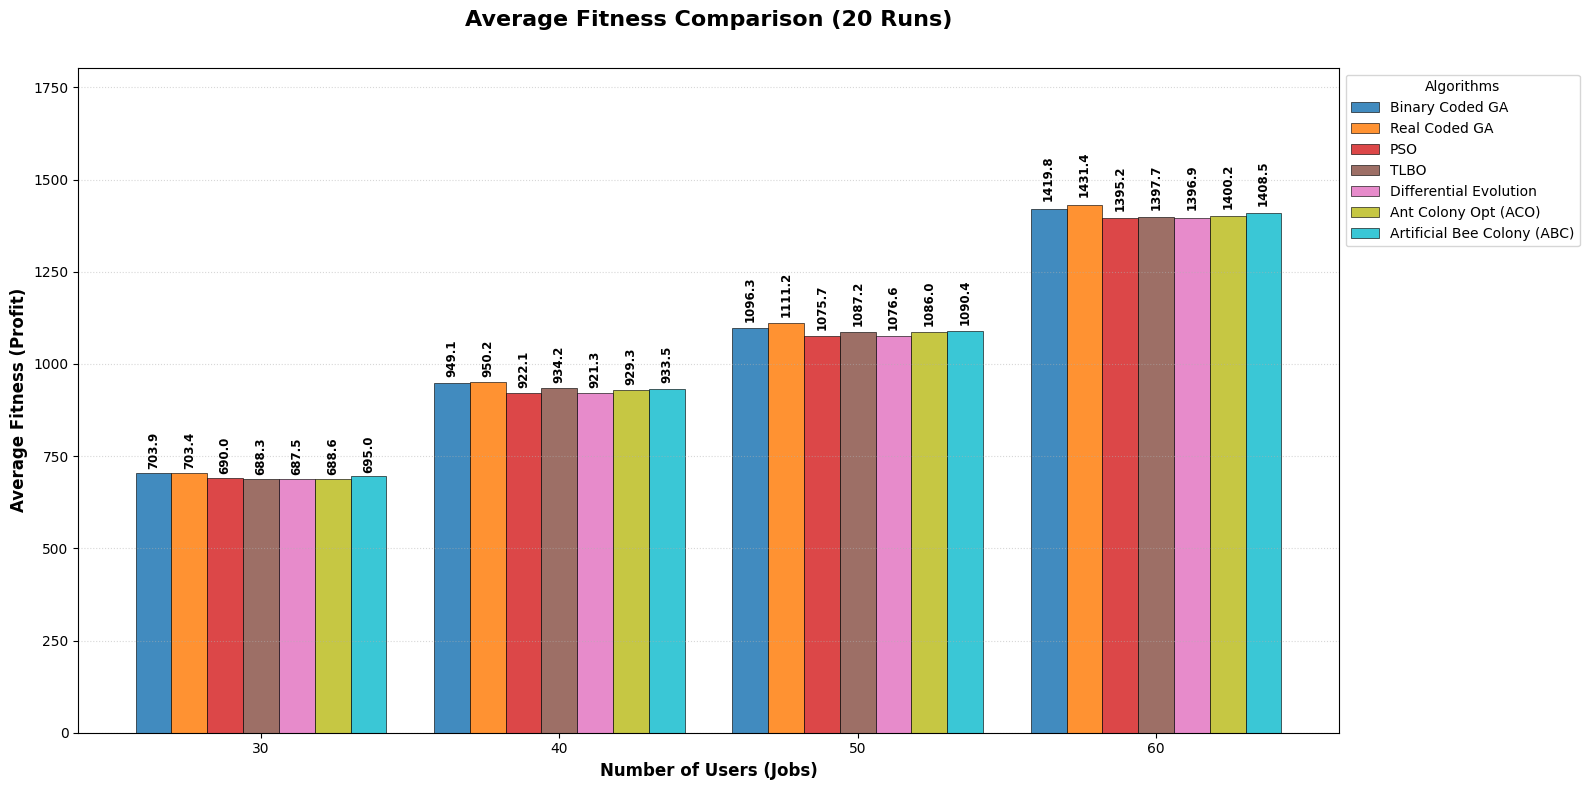

C:\Users\Harshit Katiyar\AppData\Local\Temp\ipykernel_7528\2558845982.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_algos).colors


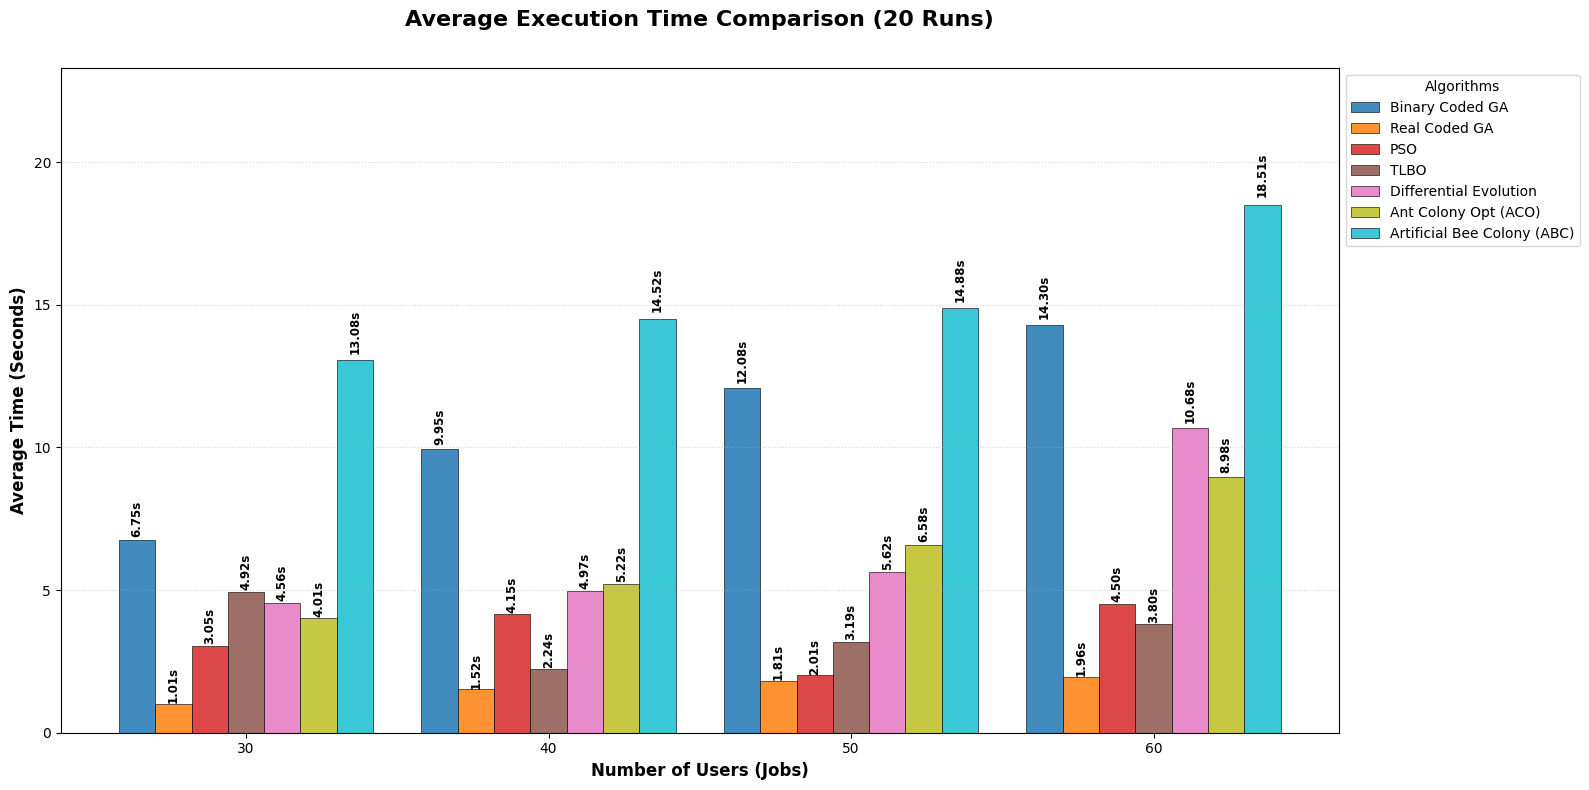

In [15]:
plot_grouped_bars(job_sizes, fitness_data, 'Average Fitness Comparison (20 Runs)', 'Average Fitness (Profit)', is_fitness=True)
plot_grouped_bars(job_sizes, time_data, 'Average Execution Time Comparison (20 Runs)', 'Average Time (Seconds)', is_fitness=False)